특성데이터: 가격을 제외한 나머지  
라벨: 가격

1. 상관관계를 구하시오.
2. train, test 분할
3. 라벨: 가격분류 특성데이터: 가격분류제외 나머지
4. 3065	2015	중형	13.8	200	44.5	디젤	0	2199	1799	자동 : 가격분류 예측하시요
5. train, test  : confusion matrix, 정확도, 정밀도, 재현율, f1 score , roc 를 구하시요


In [19]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression, LinearRegression,SGDRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score,roc_curve,auc

import seaborn as sb
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family']='Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False

hDF = pd.read_excel('../data/현대자동차.xlsx')
hDF

,가격,년식,종류,연비,마력,토크,연료,하이브리드,배기량,중량,변속기,가격분류
0,1885,2015,준중형,11.8,172,21.0,가솔린,0,1999,1300,자동,일반
1,2190,2015,준중형,12.3,204,27.0,가솔린,0,1591,1300,자동,고가
2,1135,2015,소형,15.0,100,13.6,가솔린,0,1368,1035,수동,일반
3,1645,2014,소형,14.0,140,17.0,가솔린,0,1591,1090,자동,일반
4,1960,2015,대형,9.6,175,46.0,디젤,0,2497,1990,자동,일반
...,...,...,...,...,...,...,...,...,...,...,...,...
66,3802,2015,중형,8.5,290,34.8,가솔린,0,3342,1901,자동,고가
67,1270,2012,소형,13.3,108,13.9,가솔린,0,1396,1040,자동,일반
68,2430,2015,준중형,12.8,186,41.0,디젤,0,1995,1665,자동,고가
69,2870,2015,중형,17.7,156,19.3,가솔린,1,1999,1585,자동,고가


라벨: 가격분류 /  특성데이터: 가격분류제외 나머지

In [20]:
x_data = hDF[['가격', '년식', '종류', '연비', '마력', '토크', '연료', '하이브리드', '배기량', '중량', '변속기']]
y_data = hDF[['가격분류']]

In [21]:
y_replace = y_data.replace({'일반': 0, '고가': 1})

C:\Users\Dell3571\AppData\Local\Temp\ipykernel_12796\1455620757.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y_replace = y_data.replace({'일반': 0, '고가': 1})


1. 상관관계를 구하시오.

In [22]:
cat_cols = ['종류','연료','변속기','가격분류']
num_cols = ['가격','년식','연비','마력','토크','배기량','중량','하이브리드']

cat_df = pd.get_dummies(
	hDF[cat_cols],
	drop_first=True,
	dtype=int
)

In [23]:
eda_df = pd.concat(
	[hDF[num_cols], cat_df],
	axis=1
)

In [24]:
corr = eda_df.corr()
corr

,가격,년식,연비,마력,토크,배기량,중량,하이브리드,종류_소형,종류_준중형,종류_중형,연료_가솔린,연료_디젤,변속기_자동,가격분류_일반
가격,1.000000,0.378237,-0.345488,0.893995,0.565016,0.852247,0.517288,0.043974,-0.438728,-0.157510,0.175226,0.059893,-0.004273,0.326464,-0.588956
년식,0.378237,1.000000,-0.354930,0.485245,0.538361,0.451284,0.569321,-0.079089,-0.697305,0.162189,0.240789,-0.308995,0.366423,0.181793,-0.448308
연비,-0.345488,-0.354930,1.000000,-0.499384,-0.260482,-0.659503,-0.698694,0.237268,0.473661,0.260759,0.071571,0.164325,0.028593,-0.182552,0.103280
마력,0.893995,0.485245,-0.499384,1.000000,0.662249,0.909100,0.618218,-0.112834,-0.562641,-0.109979,0.164217,0.026735,0.033106,0.303948,-0.606549
토크,0.565016,0.538361,-0.260482,0.662249,1.000000,0.616431,0.743632,-0.191790,-0.635442,-0.011317,0.223965,-0.559486,0.661371,0.131063,-0.532648
배기량,0.852247,0.451284,-0.659503,0.909100,0.616431,1.000000,0.752350,-0.052107,-0.573032,-0.257705,0.022580,-0.073506,0.063345,0.215127,-0.435205
중량,0.517288,0.569321,-0.698694,0.618218,0.743632,0.752350,1.000000,-0.034522,-0.769690,-0.217420,0.188455,-0.590152,0.508567,0.125033,-0.473263
하이브리드,0.043974,-0.079089,0.237268,-0.112834,-0.191790,-0.052107,-0.034522,1.000000,-0.113288,0.062809,0.071876,0.067062,-0.179670,0.131533,-0.195736
종류_소형,-0.438728,-0.697305,0.473661,-0.562641,-0.635442,-0.573032,-0.769690,-0.113288,1.000000,-0.279145,-0.267304,0.464389,-0.393124,-0.186824,0.578780
종류_준중형,-0.157510,0.162189,0.260759,-0.109979,-0.011317,-0.257705,-0.217420,0.062809,-0.279145,1.000000,-0.256495,-0.110810,0.116089,-0.059419,-0.067230


2. train, test 분할

In [25]:
x_train, x_test, y_train, y_test = train_test_split( x_data, y_data, test_size=0.3, stratify=y_data)

3. 3065	2015	중형	13.8	200	44.5	디젤	0	2199	1799	자동 : 가격분류 예측하시오.

In [26]:
m_list = [('enc', OneHotEncoder(), ['년식','종류','연료','배기량','중량', '변속기']),
          ('scale', StandardScaler(), ['가격','연비','마력','토크'])]

In [27]:
cat_cols = ['종류','연료','변속기']
num_cols = ['가격','년식','연비','마력','토크','배기량','중량','하이브리드']

preprocess = ColumnTransformer([
	('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
	('num', StandardScaler(), num_cols)
], remainder='passthrough')

pipe = Pipeline([
	('preprocess', preprocess),
	('model', LogisticRegression(max_iter=500))
])

pipe.fit(x_train, y_train)

c:\Python310\lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,steps,"[('preprocess', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [28]:
frame_d = pd.DataFrame({'가격':[3065],'년식':[2015],'종류':['중형'],'연비':[13],'마력':[200],'토크':[44.5],'연료':['디젤'],
                        '하이브리드':[0],'배기량':[2199],'중량':[1799],'변속기':['자동']})

In [29]:
pipe.predict(frame_d)   # '고가'=1, '일반'=0

array(['고가'], dtype=object)

4. train, test  : confusion matrix, 정확도, 정밀도, 재현율, f1 score , roc 를 구하시오.

In [30]:
# pred_tr

In [31]:
pred_tr = pipe.predict(x_train)
pred_ts = pipe.predict(x_test)

In [32]:
c_tr = confusion_matrix(y_train, pred_tr)
c_tr

array([[25,  1],
       [ 1, 22]])

In [33]:
c_ts = confusion_matrix(y_test, pred_ts)
c_ts

array([[12,  0],
       [ 3,  7]])

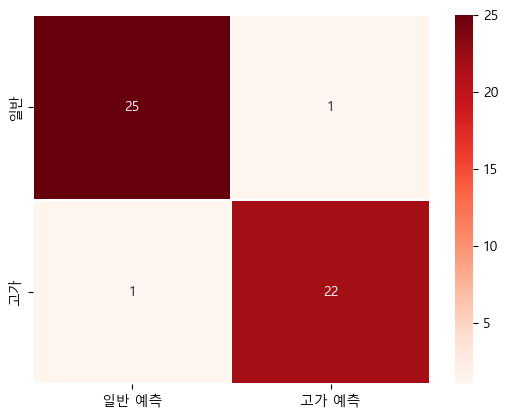

In [34]:
sb.heatmap( c_tr, annot=True, fmt='d',linewidths=0.2, cmap='Reds',
           xticklabels=['일반 예측','고가 예측'],
           yticklabels=['일반','고가'])
plt.show()

In [35]:
print('정확도', accuracy_score(y_train, pred_tr) )
print('정밀도', precision_score(y_train, pred_tr, pos_label='고가'))
print('재현율', recall_score(y_train, pred_tr, pos_label='고가') )
print('f1 score', f1_score(y_train, pred_tr, pos_label='고가') )

정확도 0.9591836734693877
정밀도 0.9615384615384616
재현율 0.9615384615384616
f1 score 0.9615384615384616


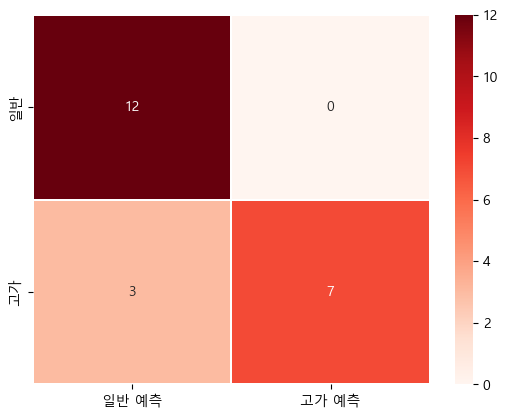

In [36]:
sb.heatmap( c_ts, annot=True, fmt='d',linewidths=0.2, cmap='Reds',
           xticklabels=['일반 예측','고가 예측'],
           yticklabels=['일반','고가'])
plt.show()

In [37]:
print('정확도', accuracy_score(y_test, pred_ts) )
print('정밀도', precision_score(y_test, pred_ts, pos_label='고가') )
print('재현율', recall_score(y_test, pred_ts, pos_label='고가') )
print('f1 score', f1_score(y_test, pred_ts, pos_label='고가') )

정확도 0.8636363636363636
정밀도 0.8
재현율 1.0
f1 score 0.8888888888888888
